In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("../data/processed/final_happiness_dataset.csv")

df.head()

,country,year,happiness_rank,happiness_score,gdp,family,health,freedom,generosity,corruption
0,Switzerland,2015,1.0,7.587,1.39651,1.34951,0.94143,0.66557,0.29678,0.41978
1,Iceland,2015,2.0,7.561,1.30232,1.40223,0.94784,0.62877,0.43630,0.14145
2,Denmark,2015,3.0,7.527,1.32548,1.36058,0.87464,0.64938,0.34139,0.48357
3,Norway,2015,4.0,7.522,1.45900,1.33095,0.88521,0.66973,0.34699,0.36503
4,Canada,2015,5.0,7.427,1.32629,1.32261,0.90563,0.63297,0.45811,0.32957


In [3]:
print(df.shape)
print(df.columns.tolist())
df.info()

(781, 10)
['country', 'year', 'happiness_rank', 'happiness_score', 'gdp', 'family', 'health', 'freedom', 'generosity', 'corruption']
<class 'pandas.DataFrame'>
RangeIndex: 781 entries, 0 to 780
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          781 non-null    str    
 1   year             781 non-null    int64  
 2   happiness_rank   781 non-null    float64
 3   happiness_score  781 non-null    float64
 4   gdp              781 non-null    float64
 5   family           781 non-null    float64
 6   health           781 non-null    float64
 7   freedom          781 non-null    float64
 8   generosity       781 non-null    float64
 9   corruption       781 non-null    float64
dtypes: float64(8), int64(1), str(1)
memory usage: 61.1 KB


In [5]:
df.describe()

,year,happiness_rank,happiness_score,gdp,family,health,freedom,generosity,corruption
count,781.000000,781.000000,781.000000,781.000000,781.000000,781.000000,781.000000,781.000000,781.000000
mean,2016.992318,78.773367,5.377232,0.914537,1.078780,0.612342,0.411254,0.218618,0.125436
std,1.417814,45.162398,1.127071,0.405403,0.329581,0.248459,0.152911,0.122394,0.105816
min,2015.000000,1.000000,2.693000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2016.000000,40.000000,4.509000,0.605000,0.870210,0.440060,0.310480,0.130000,0.054000
50%,2017.000000,79.000000,5.321000,0.982000,1.125000,0.647239,0.431000,0.202000,0.091000
75%,2018.000000,118.000000,6.182000,1.233748,1.328000,0.808000,0.531000,0.279060,0.156030
max,2019.000000,158.000000,7.769000,1.870766,1.644000,1.141000,0.724000,0.838075,0.551910


In [6]:
# Correlation Analysis

correlation_matrix = df.corr(numeric_only=True)

correlation_matrix

,year,happiness_rank,happiness_score,gdp,family,health,freedom,generosity,corruption
year,1.000000,-0.006594,0.005946,0.017230,0.368585,0.130138,0.011118,-0.192416,-0.122264
happiness_rank,-0.006594,1.000000,-0.992053,-0.795110,-0.647420,-0.744099,-0.540151,-0.118290,-0.372781
happiness_score,0.005946,-0.992053,1.000000,0.789719,0.651246,0.742843,0.553365,0.138142,0.398418
gdp,0.017230,-0.795110,0.789719,1.000000,0.592889,0.787752,0.345615,-0.013646,0.306307
family,0.368585,-0.647420,0.651246,0.592889,1.000000,0.573252,0.419795,-0.037597,0.126401
health,0.130138,-0.744099,0.742843,0.787752,0.573252,1.000000,0.341155,0.010718,0.250512
freedom,0.011118,-0.540151,0.553365,0.345615,0.419795,0.341155,1.000000,0.290564,0.459593
generosity,-0.192416,-0.118290,0.138142,-0.013646,-0.037597,0.010718,0.290564,1.000000,0.318920
corruption,-0.122264,-0.372781,0.398418,0.306307,0.126401,0.250512,0.459593,0.318920,1.000000


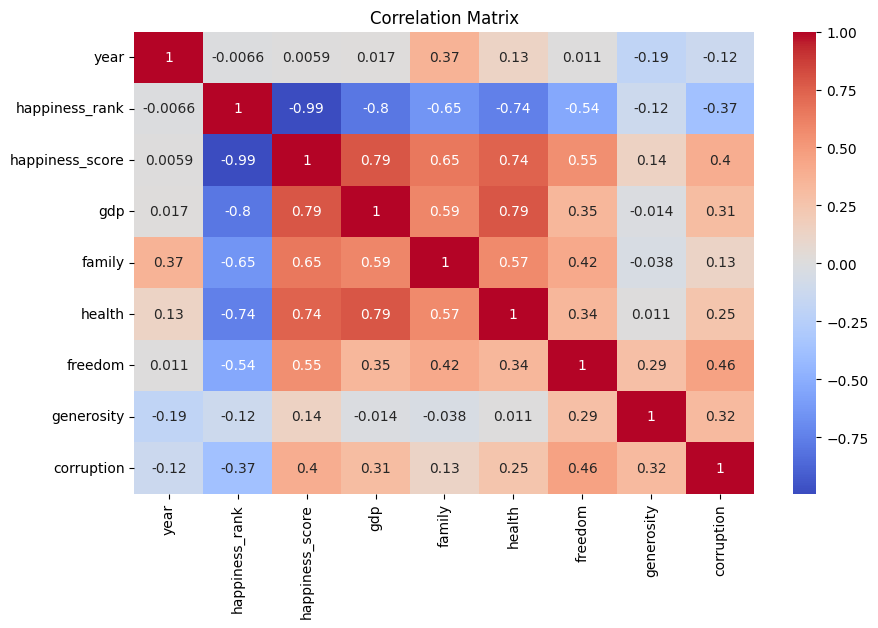

In [12]:
plt.figure(figsize=(10,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

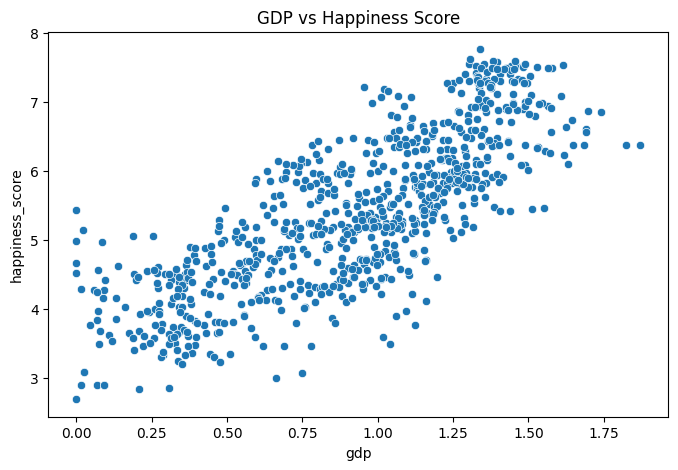

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="gdp",
    y="happiness_score"
)

plt.title("GDP vs Happiness Score")
plt.show()

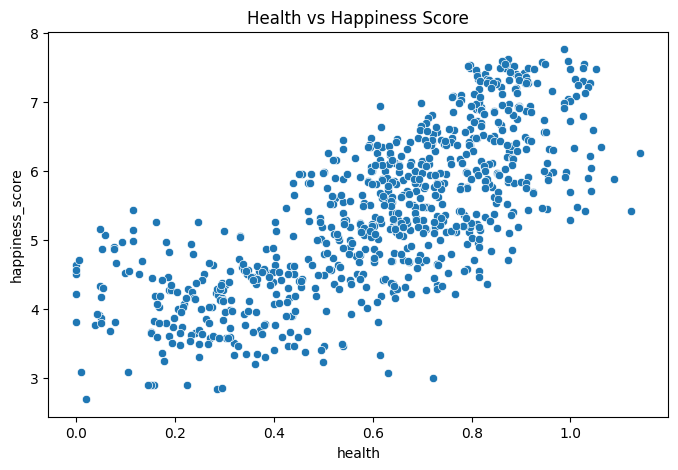

In [22]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="health",
    y="happiness_score"
)

plt.title("Health vs Happiness Score")
plt.show()

# Feature Engineering Decisions

The selected features for the regression model were:

- gdp
- family
- health
- freedom
- generosity
- corruption

These variables were selected because they show meaningful relationships
with the happiness score and are consistently available across all datasets.

Correlation analysis suggests that GDP, family/social support, health,
and freedom have stronger positive relationships with happiness score.

## Avoiding Target Leakage

The variable `happiness_rank` was excluded from the model because it is
directly derived from the happiness score and could introduce target leakage.

The `country` column was also excluded because it is categorical and not
required for this regression task.

## Scaling Decision

Feature scaling was not applied because Linear Regression can still perform
adequately with the current feature ranges, and model optimization is not
the primary focus of this workshop.

## Train Regression Model

In [ ]:
# features and target
features = [
    "gdp",
    "family",
    "health",
    "freedom",
    "generosity",
    "corruption"
]

target = "happiness_score"

X = df[features]
y = df[target]

In [16]:
# ---Train/Test Split---
# Split dataset into training and testing sets
# 70% training data
# 30% testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (546, 6)
X_test shape: (235, 6)
y_train shape: (546,)
y_test shape: (235,)


In [17]:
# Train Linear Regression model

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


## Model Evaluation

In [18]:
# Generate predictions using test data

y_pred = model.predict(X_test)

# Evaluation metrics

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics")
print("MAE:", mae) # Mean Absolute Error
print("RMSE:", rmse)
print("R²:", r2)

Model Evaluation Metrics
MAE: 0.43214584081745866
RMSE: 0.5566189459211589
R²: 0.7518804887905026


In [19]:
# Save trained model for Kafka streaming inference

joblib.dump(model, "../models/model.pkl")

print("Model saved successfully.")

Model saved successfully.


# Model Evaluation Results

The Linear Regression model produced good results for predicting the happiness score of each country.

## MAE (Mean Absolute Error)

The MAE result was approximately 0.43. This means that, on average, the model predictions are about 0.43 points different from the real happiness score.

Considering that happiness scores usually range between 2 and 8 points, this is a relatively small prediction error.

## RMSE (Root Mean Squared Error)

The RMSE value was approximately 0.56. This metric is useful because it gives more importance to larger prediction errors.

The result shows that the model is able to make predictions with relatively low error and without large deviations in most cases.

## R² Score

The model achieved an R² score of approximately 0.75.

This means that around 75% of the variation in happiness score can be explained by the selected features used in the model.

The most relevant features included:
- GDP
- Family/Social Support
- Health
- Freedom
- Generosity
- Corruption Perception

The correlation analysis also showed that GDP, health, and family/social support have strong positive relationships with happiness score.

## Final Conclusion

Overall, the model performs well for this workshop. The results show that the selected variables are useful for predicting happiness score, and the model is accurate enough to be integrated into the Kafka streaming prediction pipeline.